# Human Trafficking Dataset
**Bayesian ML Final Project** | Bhavya, Jiwon, Noah, Sieon, Mateo

Datasets: Polaris Hotline · OVC · CTDC (aggregated + raw ~48k) · Top 30 Countries · Crosstab

## 0. Setup & Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

def safe_load(path):
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            continue
    raise ValueError(f'Cannot load {path}')

print('✅ Setup complete')

✅ Setup complete


## 0b. Dataset Overview Summary

In [5]:
files = {
    '01 Polaris Hotline': './Datasets/01_polaris_hotline_signals_fy2013_2024.csv',
    '02 OVC Victims Served': './Datasets/02_ovc_victims_served_fy23_fy24.csv',
    '03 CTDC Year×Type': './Datasets/03_ctdc_global_by_year_exploitation_type.csv',
    '04 CTDC Means of Control': './Datasets/04_ctdc_means_of_control_by_exploitation.csv',
    '05 CTDC Top 30 Countries': './Datasets/05_ctdc_top30_countries_of_exploitation.csv',
    '06 CTDC Age×Gender×Exploitation': './Datasets/06_ctdc_age_gender_exploitation_crosstab.csv',
    'GLOBAL CTDC Raw (~48k)': './Datasets/The Global Dataset 14 Apr 2020.csv',
}

rows = []
for label, path in files.items():
    try:
        df = safe_load(path)
        rows.append({'Dataset': label, 'Rows': df.shape[0], 'Cols': df.shape[1],
                     'Missing %': f"{df.isnull().mean().mean()*100:.1f}%",
                     'Num cols': len(df.select_dtypes(include='number').columns),
                     'Cat cols': len(df.select_dtypes(include='object').columns)})
    except Exception as e:
        rows.append({'Dataset': label, 'Rows': 'ERR', 'Cols': str(e),
                     'Missing %': '', 'Num cols': '', 'Cat cols': ''})

pd.DataFrame(rows)

,Dataset,Rows,Cols,Missing %,Num cols,Cat cols
0,01 Polaris Hotline,12,5,8.3%,5,0
1,02 OVC Victims Served,8,8,0.0%,7,1
2,03 CTDC Year×Type,18,16,0.0%,16,0
3,04 CTDC Means of Control,32,6,1.0%,4,2
4,05 CTDC Top 30 Countries,30,6,0.0%,5,1
5,06 CTDC Age×Gender×Exploitation,18,7,0.0%,5,2
6,GLOBAL CTDC Raw (~48k),48801,64,1.6%,51,13


---
## 1. Polaris Hotline Signals FY2013–2024
> **Role**: Detection/awareness proxy · **Use in model**: BSTS/DLM time-series input

In [7]:
df01 = safe_load('./Datasets/01_polaris_hotline_signals_fy2013_2024.csv')
print(f'Shape: {df01.shape}')
display(df01)

Shape: (12, 5)


,fiscal_year,total_signals,substantive_signals,signals_from_potential_victims,potential_situations_identified
0,2013,32438,NaN,2641,4796
1,2014,39134,NaN,2602,5166
2,2015,36916,NaN,3487,5418
3,2016,54823,NaN,4608,7405
4,2017,68938,NaN,4626,8686
5,2018,116940,47709.0,7136,10658
6,2019,136990,56644.0,10362,11852
7,2020,195100,65959.0,13129,11193
8,2021,219380,66308.0,13538,10983
9,2022,212167,55731.0,10190,10013


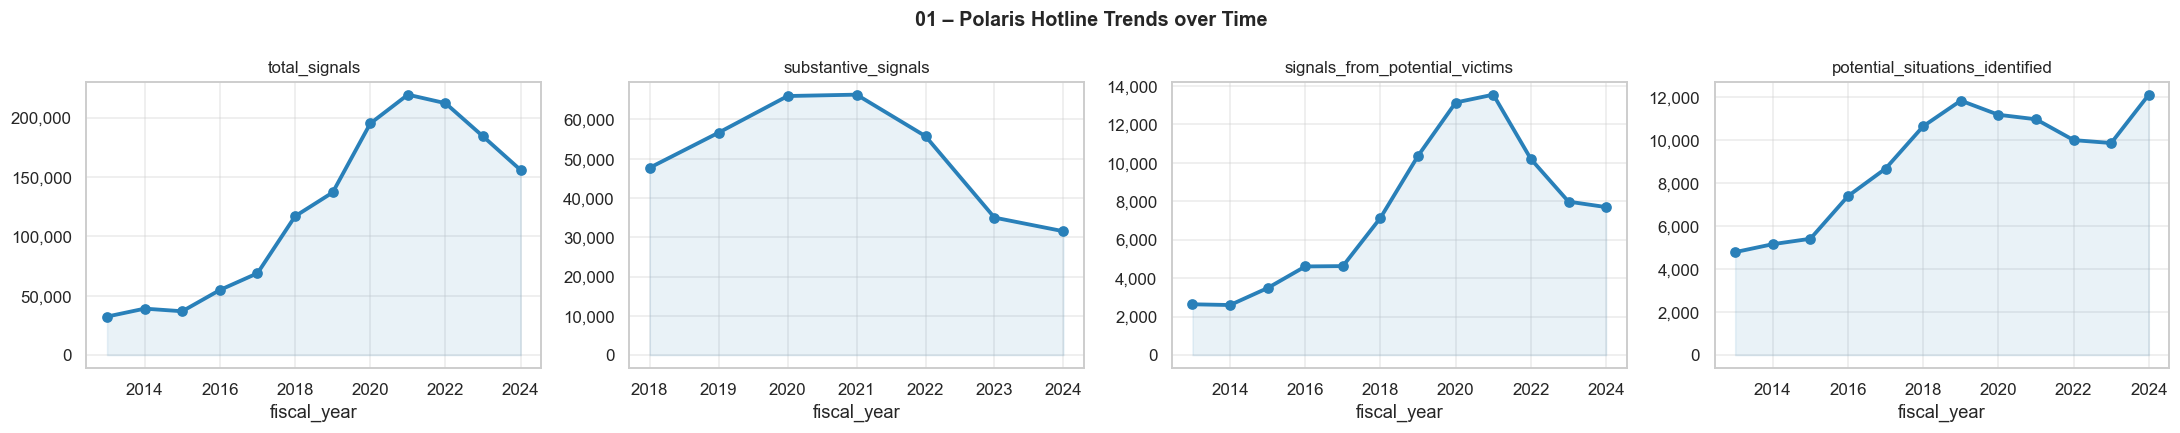

In [8]:
# Detect year col and numeric cols
year_col = next((c for c in df01.columns if any(k in c.lower() for k in ['year','fy','fiscal'])), df01.columns[0])
num_cols = [c for c in df01.select_dtypes(include='number').columns if c != year_col]

fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 4))
if len(num_cols) == 1: axes = [axes]
for ax, col in zip(axes, num_cols):
    ax.plot(df01[year_col], df01[col], marker='o', linewidth=2.5, color='#2980b9')
    ax.fill_between(df01[year_col], df01[col], alpha=0.1, color='#2980b9')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(year_col)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    ax.grid(True, alpha=0.4)
fig.suptitle('01 – Polaris Hotline Trends over Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

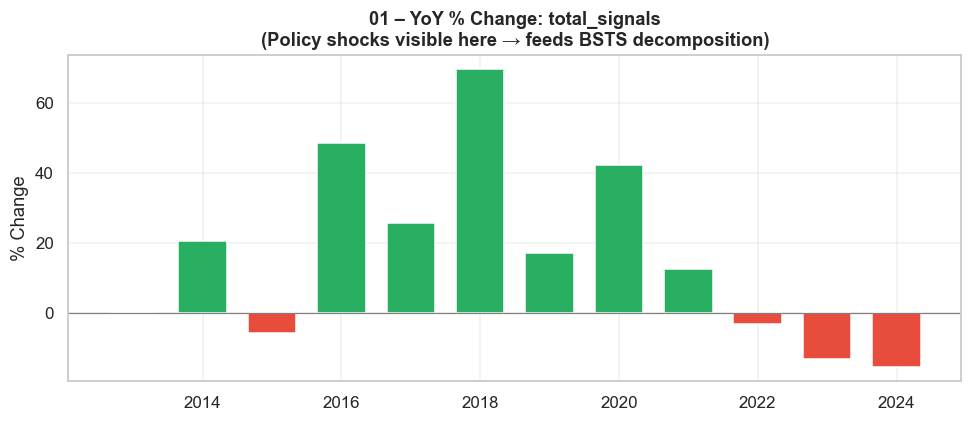

In [9]:
# YoY % Change
if len(num_cols) >= 1:
    df01s = df01.sort_values(year_col).copy()
    col = num_cols[0]
    df01s['yoy'] = df01s[col].pct_change() * 100
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['#e74c3c' if v < 0 else '#27ae60' for v in df01s['yoy'].fillna(0)]
    ax.bar(df01s[year_col], df01s['yoy'].fillna(0), color=colors, edgecolor='white', width=0.7)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_title(f'01 – YoY % Change: {col}\n(Policy shocks visible here → feeds BSTS decomposition)', fontweight='bold')
    ax.set_ylabel('% Change')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## 2. OVC Victims Served FY23–FY24
> **Role**: Service capacity proxy (federally audited) · **Note**: capacity ≠ prevalence

In [11]:
df02 = safe_load('./Datasets/02_ovc_victims_served_fy23_fy24.csv')
print(f'Shape: {df02.shape}')
display(df02)

Shape: (8, 8)


,fiscal_year,quarter,sex_trafficking,labor_trafficking,eligible_family_members,undetermined,sex_and_labor,quarterly_total
0,2024,Q1,2429,614,564,368,296,4271
1,2024,Q2,2385,659,492,268,261,4065
2,2024,Q3,2262,571,486,224,223,3766
3,2024,Q4,1990,559,468,325,197,3539
4,2023,Q1,1823,532,500,109,182,3146
5,2023,Q2,1971,610,558,208,84,3431
6,2023,Q3,2000,463,414,128,190,3195
7,2023,Q4,1892,451,425,201,178,3147


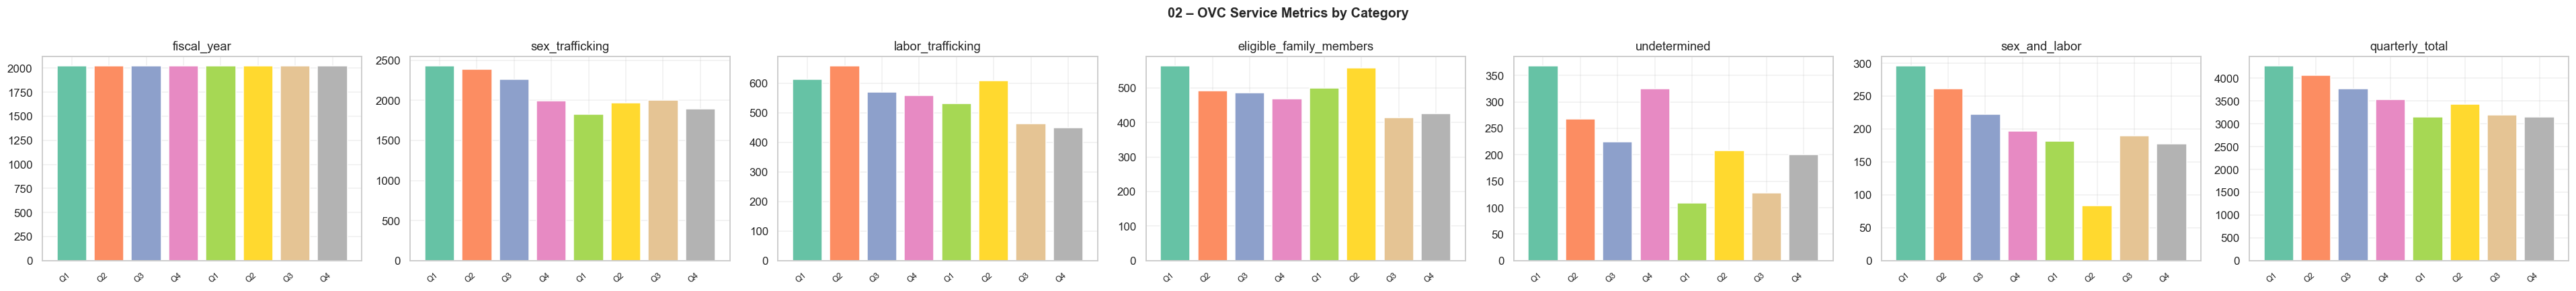

In [12]:
num_cols_02 = df02.select_dtypes(include='number').columns.tolist()
cat_cols_02 = df02.select_dtypes(include='object').columns.tolist()

if num_cols_02 and cat_cols_02:
    fig, axes = plt.subplots(1, len(num_cols_02), figsize=(5*len(num_cols_02), 4))
    if len(num_cols_02) == 1: axes = [axes]
    palette = sns.color_palette('Set2', len(df02))
    for ax, col in zip(axes, num_cols_02):
        ax.bar(range(len(df02)), df02[col], color=palette, edgecolor='white')
        ax.set_xticks(range(len(df02)))
        ax.set_xticklabels(df02[cat_cols_02[0]], rotation=40, ha='right', fontsize=8)
        ax.set_title(col)
        ax.grid(True, alpha=0.3)
    fig.suptitle('02 – OVC Service Metrics by Category', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

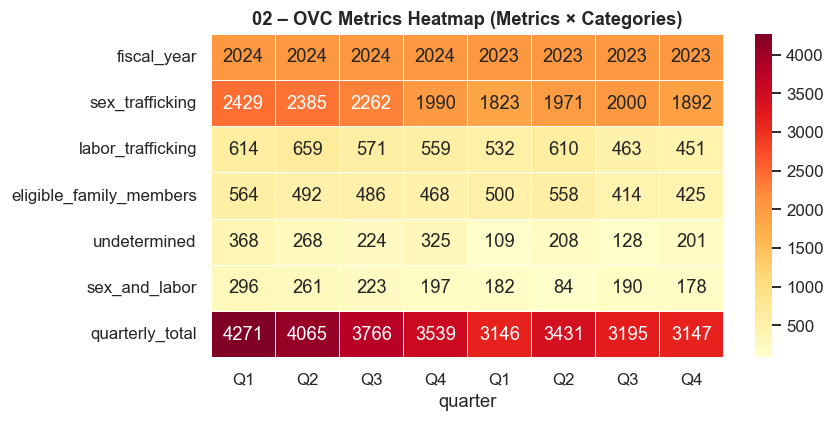

In [13]:
# Heatmap
if len(num_cols_02) >= 2 and cat_cols_02:
    fig, ax = plt.subplots(figsize=(8, 4))
    hm = df02.set_index(cat_cols_02[0])[num_cols_02].T
    sns.heatmap(hm, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
    ax.set_title('02 – OVC Metrics Heatmap (Metrics × Categories)', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 3. CTDC Global by Year & Exploitation Type
> **Role**: Temporal trend of exploitation types · feeds Hierarchical Beta-Binomial

In [15]:
df03 = safe_load('./Datasets/03_ctdc_global_by_year_exploitation_type.csv')
print(f'Shape: {df03.shape}')
display(df03.head(10))

Shape: (18, 16)


,year,n_records,n_female,n_male,forced_labour_n,forced_labour_denom,sexual_exploit_n,sexual_exploit_denom,sex_and_labour_n,sex_and_labour_denom,forced_marriage_n,forced_marriage_denom,organ_removal_n,organ_removal_denom,slavery_practices_n,slavery_practices_denom
0,2002,1026,1026,0,0,919,867,919,0,919,0,845,0,919,0,0
1,2003,357,342,15,0,357,357,357,0,357,0,320,0,357,0,0
2,2004,223,223,0,0,223,160,223,0,223,0,223,0,223,0,0
3,2005,1455,1030,425,817,1431,492,1431,0,1431,0,1431,0,1431,0,0
4,2006,1423,1134,289,622,1181,318,1078,0,1078,0,1078,0,1078,0,0
5,2007,1417,1072,345,251,563,344,563,0,563,0,563,0,563,0,0
6,2008,802,640,162,66,104,23,61,0,61,0,61,0,61,0,0
7,2009,587,511,76,15,51,0,51,0,51,0,0,0,51,0,0
8,2010,943,478,465,260,271,38,275,0,248,0,0,0,248,0,0
9,2011,1340,798,542,193,193,0,168,0,168,0,0,0,168,0,0


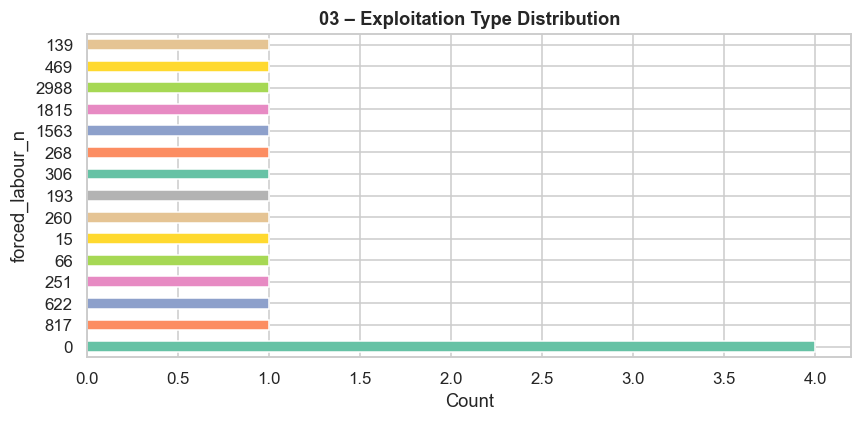

In [16]:
year_col_03 = next((c for c in df03.columns if 'year' in c.lower()), None)
type_col_03 = next((c for c in df03.columns if any(k in c.lower() for k in ['exploit','type','labour','labor'])), None)
num_cols_03 = df03.select_dtypes(include='number').columns.tolist()

if type_col_03:
    vc = df03[type_col_03].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    vc.plot(kind='barh', ax=ax, color=sns.color_palette('Set2', len(vc)))
    ax.set_title('03 – Exploitation Type Distribution', fontweight='bold')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()

---
## 4. CTDC Means of Control by Exploitation
> **Key input for Hierarchical Beta-Binomial model** – co-occurrence of control mechanisms × exploitation type

In [19]:
df04 = safe_load('./Datasets/04_ctdc_means_of_control_by_exploitation.csv')
print(f'Shape: {df04.shape}')
display(df04)

Shape: (32, 6)


,exploitation_type,means_of_control,n_positive,n_observed,raw_prevalence,beta_posterior_mean
0,forced_labour,debt_bondage,641,715,0.896503,0.895397
1,forced_labour,takes_earnings,1726,1796,0.961024,0.960512
2,forced_labour,restricts_financial_access,0,78,0.000000,0.012500
3,forced_labour,threats,1384,1428,0.969188,0.968531
4,forced_labour,psychological_abuse,1717,1777,0.966235,0.965711
5,forced_labour,physical_abuse,1035,1102,0.939201,0.938406
6,forced_labour,sexual_abuse,30,105,0.285714,0.289720
7,forced_labour,false_promises,1909,1961,0.973483,0.973001
8,forced_labour,psychoactive_substances,45,122,0.368852,0.370968
9,forced_labour,restricts_movement,1629,1685,0.966766,0.966212


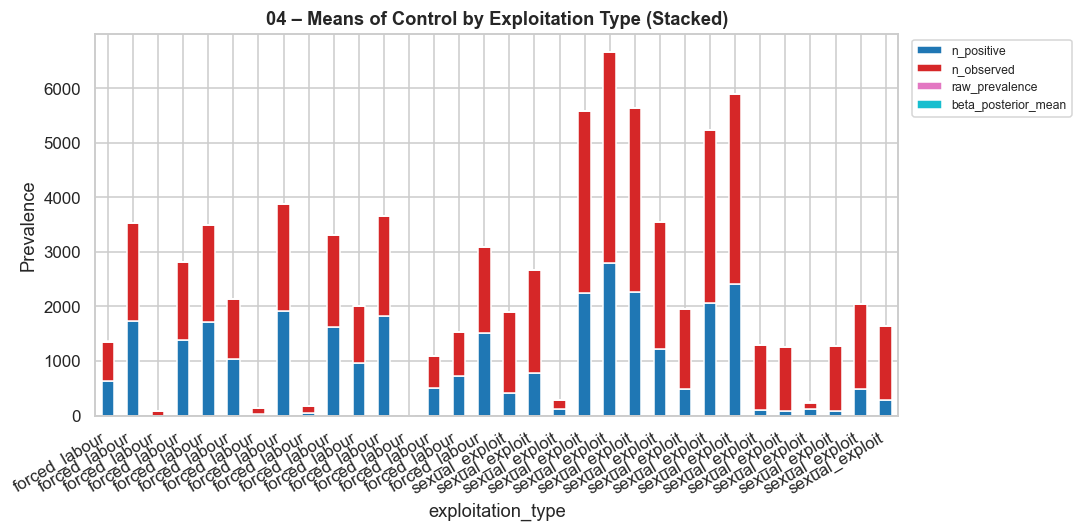

In [20]:
num_cols_04 = df04.select_dtypes(include='number').columns.tolist()
cat_cols_04 = df04.select_dtypes(include='object').columns.tolist()

if cat_cols_04 and num_cols_04:
    fig, ax = plt.subplots(figsize=(10, 5))
    df04.set_index(cat_cols_04[0])[num_cols_04].plot(kind='bar', stacked=True, ax=ax,
                                                       colormap='tab10', edgecolor='white')
    ax.set_title('04 – Means of Control by Exploitation Type (Stacked)', fontweight='bold')
    ax.set_ylabel('Prevalence')
    ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

---
## 5. CTDC Top 30 Countries of Exploitation
> **Hierarchical model motivation** – small-n countries need global pooling

In [22]:
df05 = safe_load('./Datasets/05_ctdc_top30_countries_of_exploitation.csv')
print(f'Shape: {df05.shape}')
display(df05)

Shape: (30, 6)


,CountryOfExploitation,n_records,n_female,n_male,n_forced_labour,n_sexual_exploit
0,US,12512,12168,344,197,11855
1,UA,5399,2941,2458,54,55
2,MD,4504,3615,889,0,77
3,RU,2738,819,1919,2282,478
4,PH,1988,1369,619,742,120
5,ID,1777,245,1532,1671,0
6,KH,1000,511,489,0,926
7,MY,930,762,168,379,136
8,00,844,552,292,0,0
9,GH,544,207,337,544,0


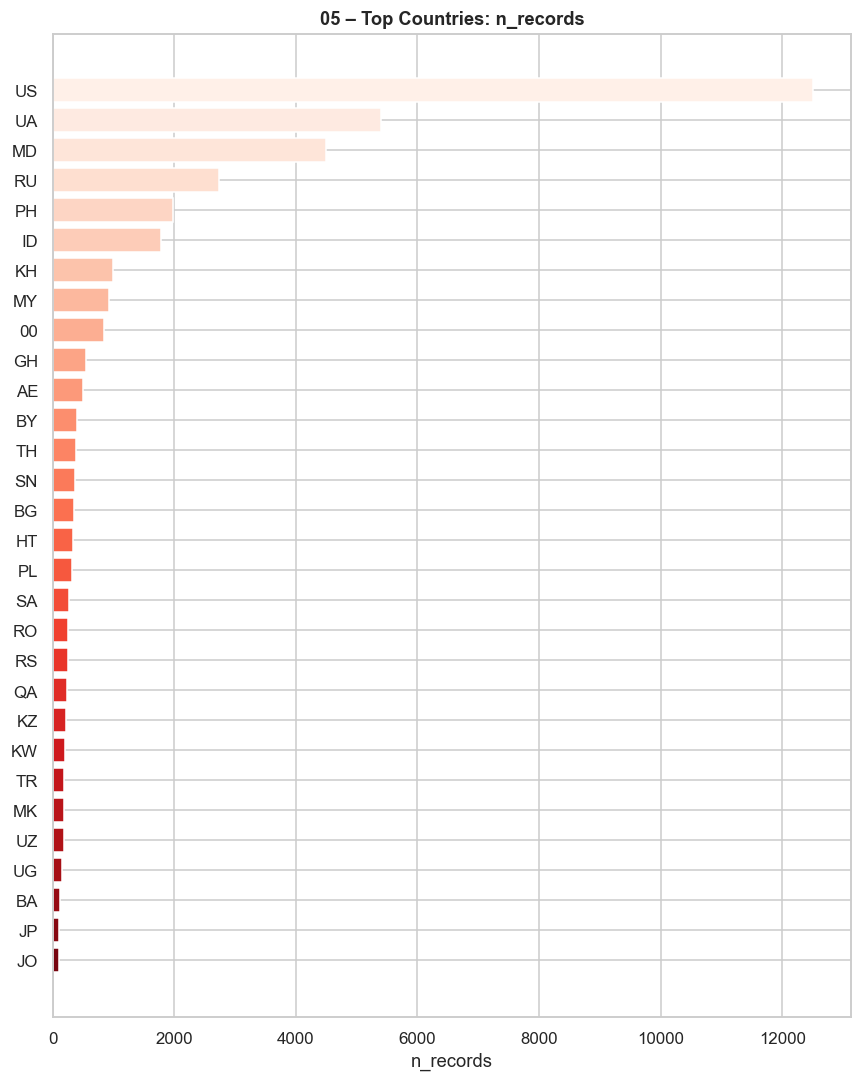

In [23]:
country_col = next((c for c in df05.columns if any(k in c.lower() for k in ['country','nation'])), df05.columns[0])
num_cols_05 = df05.select_dtypes(include='number').columns.tolist()

if num_cols_05:
    metric = num_cols_05[0]
    df05s = df05.sort_values(metric, ascending=True)
    fig, ax = plt.subplots(figsize=(8, 10))
    colors = sns.color_palette('Reds_r', len(df05s))
    ax.barh(df05s[country_col].astype(str), df05s[metric], color=colors, edgecolor='white')
    ax.set_title(f'05 – Top Countries: {metric}', fontweight='bold')
    ax.set_xlabel(metric)
    plt.tight_layout()
    plt.show()

---
## 6. CTDC Age × Gender × Exploitation Crosstab

In [26]:
df06 = safe_load('./Datasets/06_ctdc_age_gender_exploitation_crosstab.csv')
print(f'Shape: {df06.shape}')
display(df06)

Shape: (18, 7)


,ageBroad,gender,n,n_forced_labour,n_sexual_exploit,n_forced_labour_obs,n_sexual_exploit_obs
0,0--8,Female,841,101,122,223,211
1,0--8,Male,715,121,36,157,157
2,18--20,Female,4227,256,2906,3237,3238
3,18--20,Male,221,90,30,120,120
4,21--23,Female,3734,211,2325,2660,2635
5,21--23,Male,479,264,25,289,289
6,24--26,Female,2816,174,1551,1854,1854
7,24--26,Male,648,347,17,364,364
8,27--29,Female,1869,227,891,1144,1118
9,27--29,Male,772,416,0,416,403


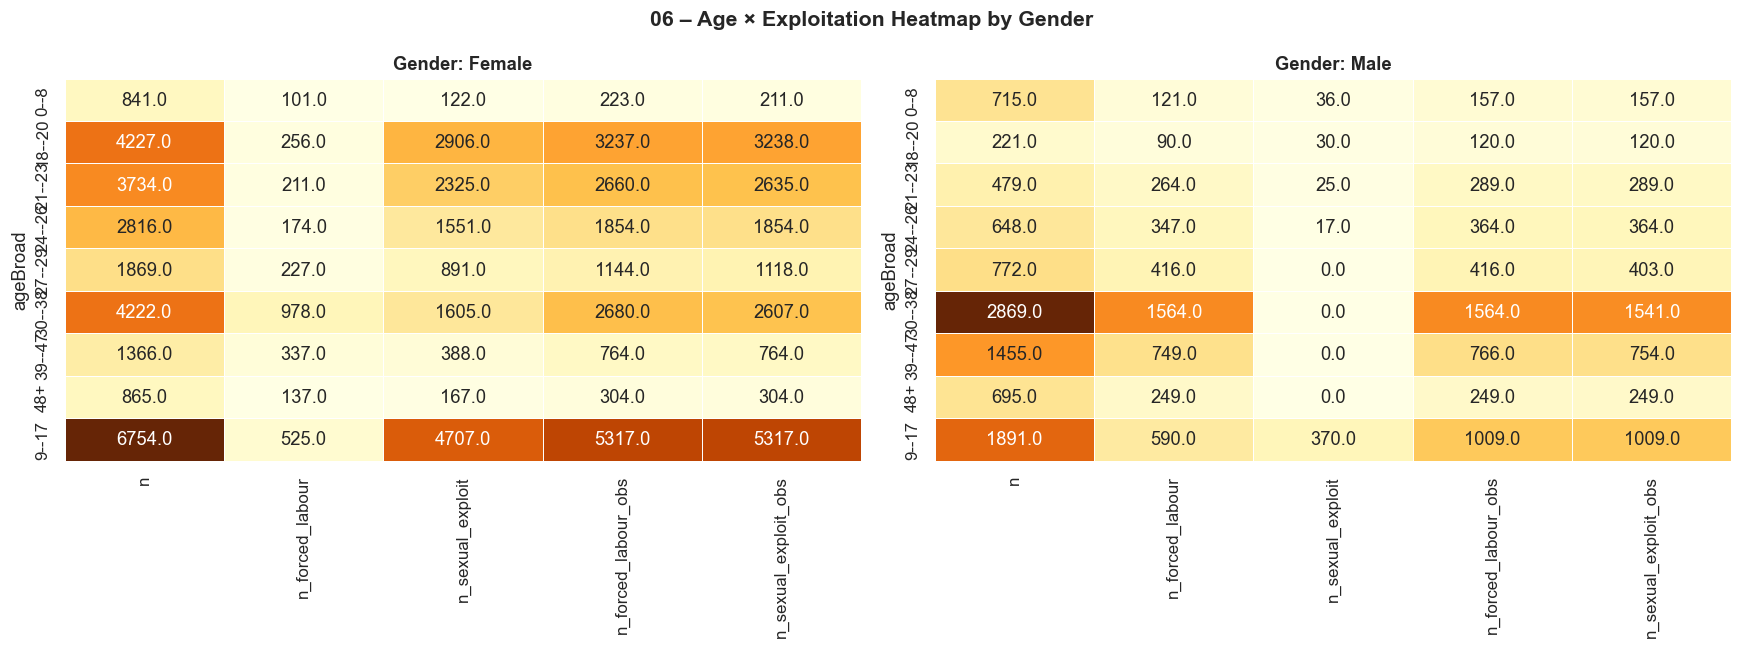

In [36]:
num_cols_06 = df06.select_dtypes(include='number').columns.tolist()
cat_cols_06 = df06.select_dtypes(include='object').columns.tolist()

# cat_cols_06[0] = ageBroad, cat_cols_06[1] = gender
age_col = cat_cols_06[0]
gender_col = cat_cols_06[1]

genders = df06[gender_col].unique()
fig, axes = plt.subplots(1, len(genders), figsize=(max(8, len(num_cols_06)*1.5) * len(genders), 6))

for ax, gender in zip(axes, genders):
    subset = df06[df06[gender_col] == gender].set_index(age_col)[num_cols_06]
    sns.heatmap(subset, annot=True, fmt='.1f', cmap='YlOrBr',
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(f'Gender: {gender}', fontweight='bold')
    ax.set_xlabel('')

fig.suptitle('06 – Age × Exploitation Heatmap by Gender', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

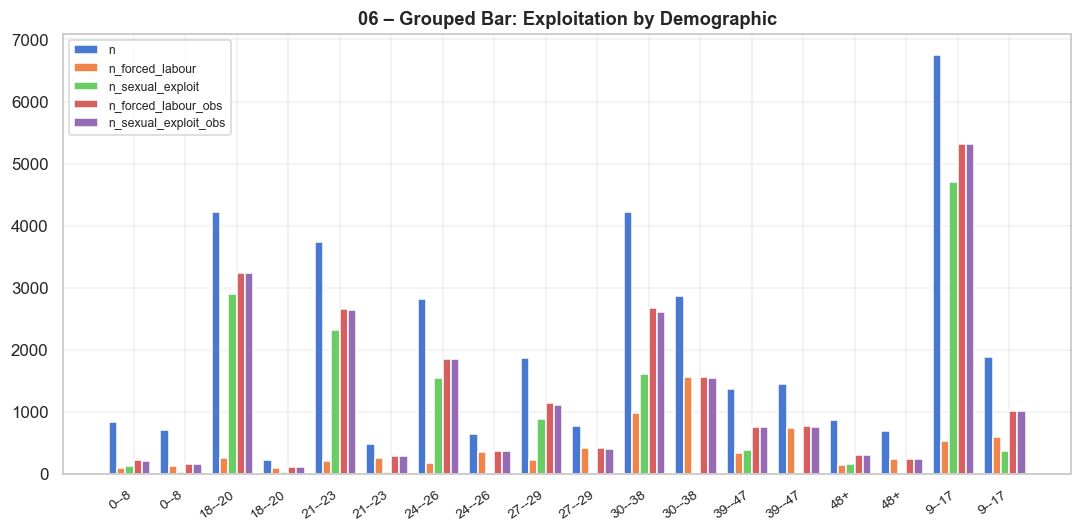

In [28]:
# Grouped bar
if cat_cols_06 and num_cols_06:
    x = np.arange(len(df06))
    w = 0.8 / len(num_cols_06)
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, col in enumerate(num_cols_06):
        ax.bar(x + i*w, df06[col], width=w, label=col)
    ax.set_xticks(x + w*len(num_cols_06)/2)
    ax.set_xticklabels(df06[cat_cols_06[0]].astype(str), rotation=35, ha='right', fontsize=9)
    ax.set_title('06 – Grouped Bar: Exploitation by Demographic', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## 7. CTDC Global Raw Dataset (~48,800 rows)
> Core dataset for Hierarchical Beta-Binomial · richest covariate structure

In [29]:
df_g = safe_load('./Datasets/The Global Dataset 14 Apr 2020.csv')
print(f'Shape: {df_g.shape}')
print(f'Columns ({len(df_g.columns)}):'); print(list(df_g.columns))
display(df_g.head(3))

Shape: (48801, 64)
Columns (64):
['By using this data you agree to the Terms of Use: https://www.ctdatacollaborative.org/terms-use', 'yearOfRegistration', 'Datasource', 'gender', 'ageBroad', 'majorityStatus', 'majorityStatusAtExploit', 'majorityEntry', 'citizenship', 'meansOfControlDebtBondage', 'meansOfControlTakesEarnings', 'meansOfControlRestrictsFinancialAccess', 'meansOfControlThreats', 'meansOfControlPsychologicalAbuse', 'meansOfControlPhysicalAbuse', 'meansOfControlSexualAbuse', 'meansOfControlFalsePromises', 'meansOfControlPsychoactiveSubstances', 'meansOfControlRestrictsMovement', 'meansOfControlRestrictsMedicalCare', 'meansOfControlExcessiveWorkingHours', 'meansOfControlUsesChildren', 'meansOfControlThreatOfLawEnforcement', 'meansOfControlWithholdsNecessities', 'meansOfControlWithholdsDocuments', 'meansOfControlOther', 'meansOfControlNotSpecified', 'meansOfControlConcatenated', 'isForcedLabour', 'isSexualExploit', 'isOtherExploit', 'isSexAndLabour', 'isForcedMarriage', 'isFor

,By using this data you agree to the Terms of Use: https://www.ctdatacollaborative.org/terms-use,yearOfRegistration,Datasource,gender,ageBroad,majorityStatus,majorityStatusAtExploit,majorityEntry,citizenship,meansOfControlDebtBondage,...,typeOfSexPrivateSexualServices,typeOfSexConcatenated,isAbduction,RecruiterRelationship,CountryOfExploitation,recruiterRelationIntimatePartner,recruiterRelationFriend,recruiterRelationFamily,recruiterRelationOther,recruiterRelationUnknown
0,NaN,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1
1,NaN,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1
2,NaN,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1


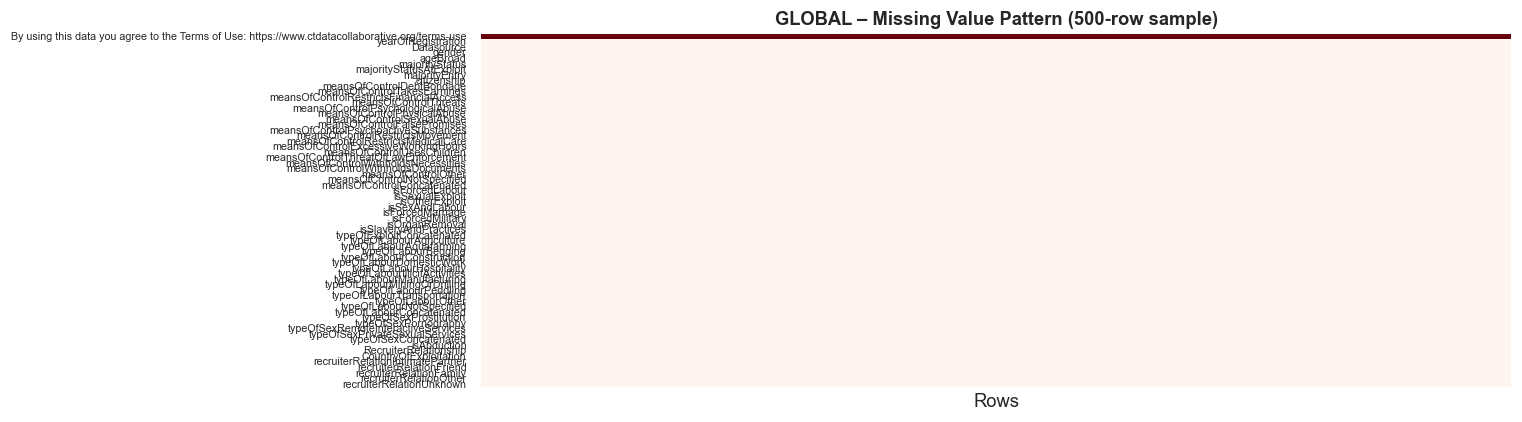

In [30]:
# Missing value pattern (500-row sample)
sample = df_g.sample(min(500, len(df_g)), random_state=42)
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(sample.isnull().astype(int).T, cmap='Reds', cbar=False,
            ax=ax, xticklabels=False, yticklabels=True)
ax.set_title('GLOBAL – Missing Value Pattern (500-row sample)', fontweight='bold')
ax.set_xlabel('Rows')
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

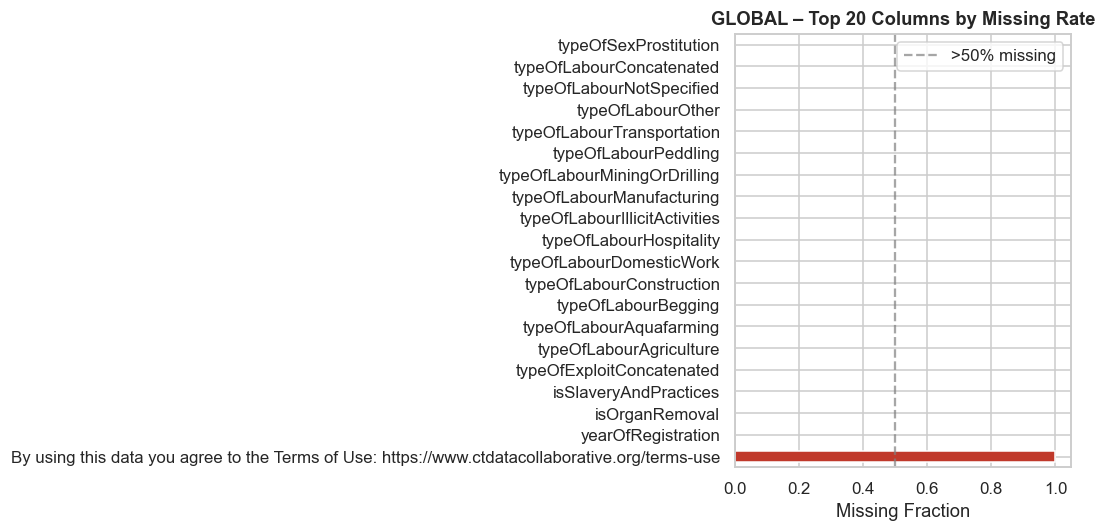

In [31]:
# Missing rate per column (top 20 most missing)
missing_rate = df_g.isnull().mean().sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 5))
missing_rate.plot(kind='barh', ax=ax, color='#c0392b')
ax.set_title('GLOBAL – Top 20 Columns by Missing Rate', fontweight='bold')
ax.set_xlabel('Missing Fraction')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='>50% missing')
ax.legend()
plt.tight_layout()
plt.show()

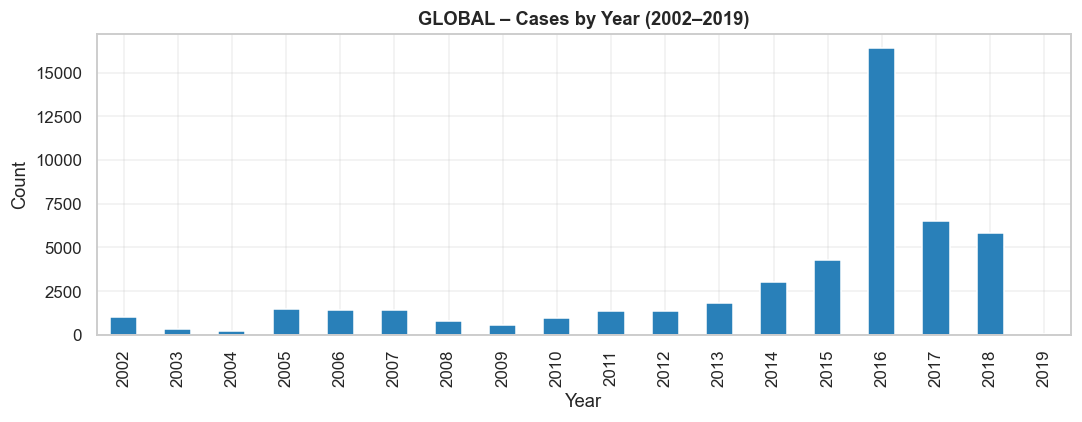

In [32]:
# Cases by year
year_col_g = next((c for c in df_g.columns if 'year' in c.lower()), None)
if year_col_g:
    fig, ax = plt.subplots(figsize=(10, 4))
    df_g[year_col_g].value_counts().sort_index().plot(kind='bar', ax=ax,
                                                       color='#2980b9', edgecolor='white')
    ax.set_title('GLOBAL – Cases by Year (2002–2019)', fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

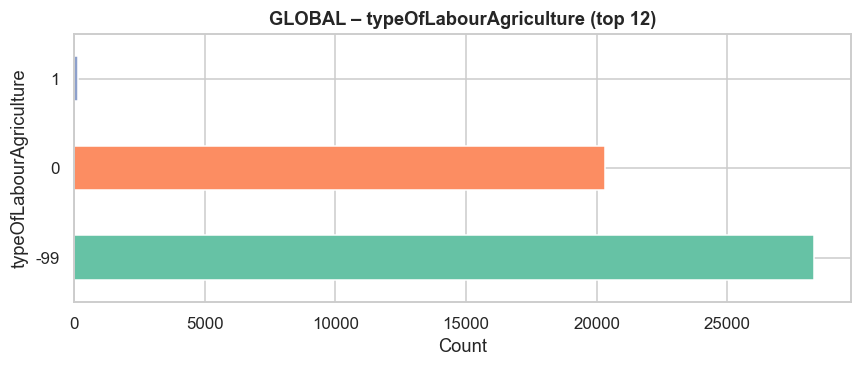

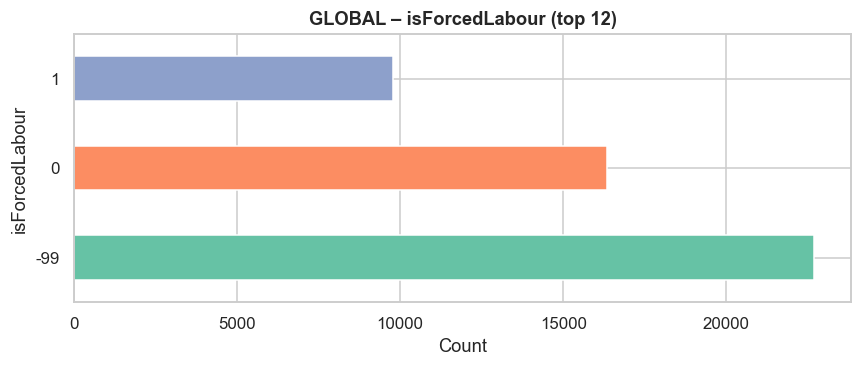

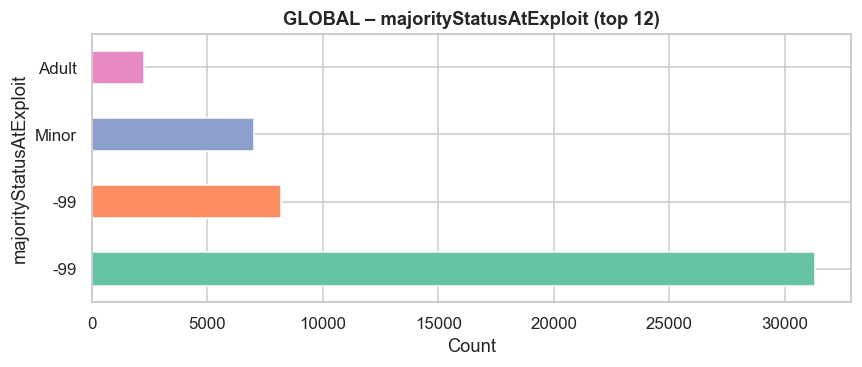

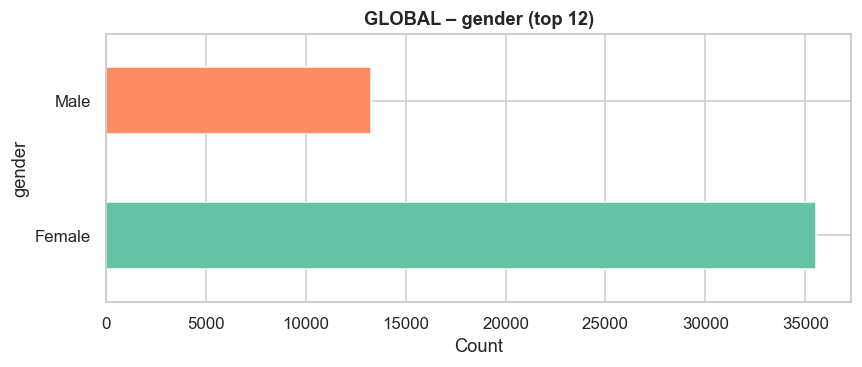

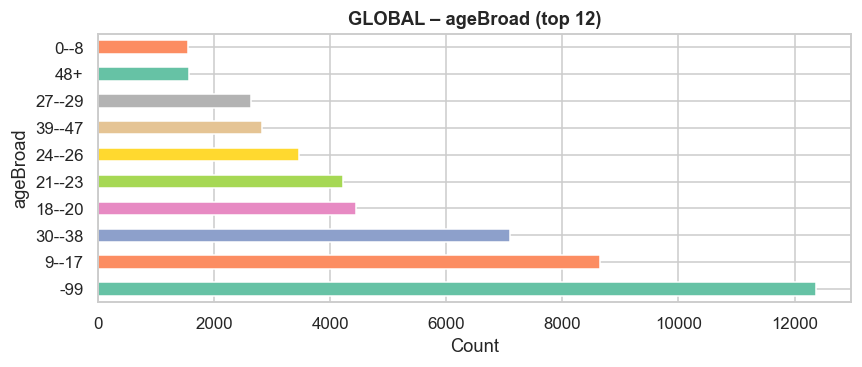

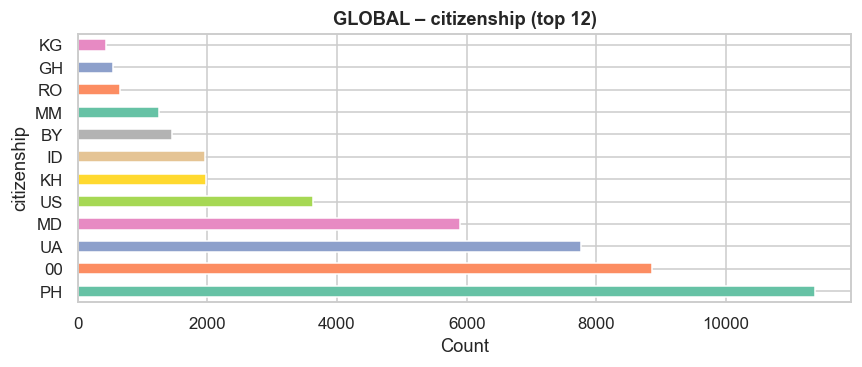

In [33]:
# Key categorical distributions
key_searches = ['typeOfLabour','labour','exploit','gender','age','citizenship','country','recruit','control','means']
plotted = 0
for kw in key_searches:
    match = [c for c in df_g.columns if kw.lower() in c.lower()]
    if match and plotted < 6:
        col = match[0]
        vc = df_g[col].value_counts().head(12)
        if len(vc) < 2: continue
        fig, ax = plt.subplots(figsize=(8, 3.5))
        vc.plot(kind='barh', ax=ax, color=sns.color_palette('Set2', len(vc)))
        ax.set_title(f'GLOBAL – {col} (top 12)', fontweight='bold')
        ax.set_xlabel('Count')
        plt.tight_layout()
        plt.show()
        plotted += 1

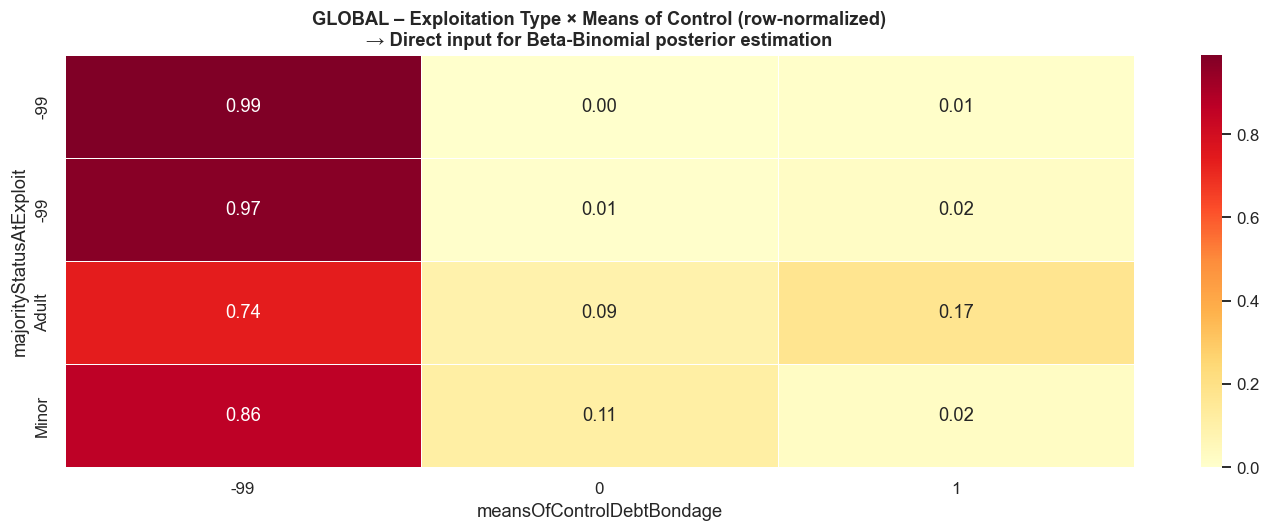

In [34]:
# Exploitation × Means of Control co-occurrence → Beta-Binomial priors
exploit_col = next((c for c in df_g.columns if any(k in c.lower() for k in ['typeoflab','labour','exploit'])), None)
control_col = next((c for c in df_g.columns if any(k in c.lower() for k in ['control','means'])), None)

if exploit_col and control_col:
    ct = pd.crosstab(df_g[exploit_col], df_g[control_col])
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.heatmap(ct_norm, annot=True, fmt='.2f', cmap='YlOrRd',
                linewidths=0.5, ax=ax)
    ax.set_title('GLOBAL – Exploitation Type × Means of Control (row-normalized)\n→ Direct input for Beta-Binomial posterior estimation', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f'exploit_col={exploit_col}, control_col={control_col}')
    print('Columns available:', list(df_g.columns))